# Exp 4 — AutoML (H2O)

H2O AutoML automatically trains and tunes a wide portfolio of algorithms:
- GBM (Gradient Boosting)
- XGBoost
- Deep Learning
- GLM (Generalized Linear Model)
- Distributed Random Forest (DRF)
- Stacked Ensembles (best-of-breed combos)

All models are trained with `balance_classes=True` to handle the 12.7% shortage imbalance.
The leaderboard ranks by AUC-ROC; we then compare top models on F1 and Recall.

**Features:** 17-feature set from Exp 2 + zone normalization
**Budget:** 5 minutes (300s) — enough for ~10–15 models on this dataset size

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))

import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns

import h2o
from h2o.automl import H2OAutoML

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    roc_auc_score, f1_score, precision_score, recall_score,
    classification_report, average_precision_score,
    precision_recall_curve, confusion_matrix
)
from sklearn.preprocessing import StandardScaler

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.4f}'.format)

# =========================================================
# 1. LOAD DATA
# =========================================================

In [ ]:
# ── Data Loading ──────────────────────────────────────────────────────────────
#  Priority 1: real LTA data  →  data/processed/training.parquet
#              Build with: python scripts/build_training_data.py
#  Priority 2: 90-day synthetic fallback (reproducible, seed=42)
# ──────────────────────────────────────────────────────────────────────────────
import pandas as pd
from pathlib import Path
from backend.preprocessing.pipeline import _SG_HOLIDAY_DATES, _SG_SCHOOL_HOLIDAY_RANGES

TRAINING_PARQUET = Path("../data/processed/training.parquet")

if TRAINING_PARQUET.exists():
    df = pd.read_parquet(TRAINING_PARQUET)
    df = df.sort_values(["zone_id", "timestamp"]).reset_index(drop=True)
    _real_data = True
    shortage_rate = df["supply_shortage"].dropna().mean()
    print(f"Real LTA data: {len(df):,} rows | shortage rate: {shortage_rate:.2%} | "
          f"{df['timestamp'].min().date()} → {df['timestamp'].max().date()}")
else:
    from backend.ingestion.loader import generate_synthetic_data
    df = generate_synthetic_data(start="2024-01-01", days=90, seed=42)
    df = df.sort_values(["zone_id", "timestamp"]).reset_index(drop=True)
    _real_data = False
    print("Synthetic data (run `python scripts/build_training_data.py` to use real LTA data)")

# ── Target: supply drops >40% in next hour? ───────────────────────────────────
if "supply_shortage" not in df.columns:
    df["taxi_count_next"] = df.groupby("zone_id")["taxi_count"].shift(-1)
    df["supply_shortage"] = (df["taxi_count_next"] < df["taxi_count"] * 0.6).astype("Int64")
    df = df.dropna(subset=["supply_shortage"]).copy()
    df["supply_shortage"] = df["supply_shortage"].astype(int)

# ── Base time features (skip if already present from parquet) ─────────────────
if "hour_of_day" not in df.columns:
    df["hour_of_day"]  = df["timestamp"].dt.hour
    df["day_of_week"]  = df["timestamp"].dt.dayofweek
    df["month"]        = df["timestamp"].dt.month
    df["is_weekend"]   = (df["day_of_week"] >= 5).astype(int)
    df["is_peak_hour"] = df["hour_of_day"].isin(set(range(7,10)) | set(range(17,21))).astype(int)

# ── Calendar flags ─────────────────────────────────────────────────────────────
ts = df["timestamp"]
tomorrow_strs = (ts + pd.Timedelta(days=1)).dt.strftime("%Y-%m-%d")
df["is_eve_holiday"] = tomorrow_strs.isin(_SG_HOLIDAY_DATES).astype(int)

if "is_school_holiday" not in df.columns:
    is_school_hol = pd.Series(False, index=df.index)
    for s_str, e_str in _SG_SCHOOL_HOLIDAY_RANGES:
        s = pd.Timestamp(s_str, tz="Asia/Singapore")
        e = pd.Timestamp(e_str, tz="Asia/Singapore") + pd.Timedelta(days=1)
        is_school_hol |= (ts >= s) & (ts < e)
    df["is_school_holiday"] = is_school_hol.astype(int)

print(f"Loaded {len(df):,} rows  |  Shortage rate: {df['supply_shortage'].mean():.2%}")

# =========================================================
# 2. QUICK SUMMARY — Prior Experiments
# =========================================================

In [3]:
PRIOR = {
    'Exp1 DT baseline (9 feat)':      {'auc': 0.8274, 'f1': 0.4128, 'precision': 0.4880, 'recall': 0.3576},
    'Exp2 DT + FE (17 feat)':         {'auc': 0.7669, 'f1': 0.3551, 'precision': 0.2909, 'recall': 0.4556},
    'Exp3 LGBM + UnderSampling':      {'auc': 0.8084, 'f1': 0.4046, 'precision': 0.3234, 'recall': 0.5404},
}

print('Prior experiment results:')
print(f'{"Experiment":<34}  {"AUC":>8}  {"F1":>8}  {"Prec":>8}  {"Recall":>8}')
print('-' * 72)
for name, m in PRIOR.items():
    print(f'{name:<34}  {m["auc"]:>8.4f}  {m["f1"]:>8.4f}  {m["precision"]:>8.4f}  {m["recall"]:>8.4f}')
print()
print('Exp 4 target: AUC > 0.88, F1 > 0.45, Recall > 0.55 via AutoML')

Prior experiment results:
Experiment                               AUC        F1      Prec    Recall
------------------------------------------------------------------------
Exp1 DT baseline (9 feat)             0.8274    0.4128    0.4880    0.3576
Exp2 DT + FE (17 feat)                0.7669    0.3551    0.2909    0.4556
Exp3 LGBM + UnderSampling             0.8084    0.4046    0.3234    0.5404

Exp 4 target: AUC > 0.88, F1 > 0.45, Recall > 0.55 via AutoML


# =========================================================
# 3. FEATURE ENGINEERING
# =========================================================
Same feature set as Exp 2/3 — all lags use shift(N ≥ 1), no leakage.

In [4]:
grp = df.groupby('zone_id')['taxi_count']

for n, col in [(1,'taxi_lag_1h'),(2,'taxi_lag_2h'),(3,'taxi_lag_3h'),
               (24,'taxi_lag_24h'),(48,'taxi_lag_48h'),(168,'taxi_lag_168h')]:
    df[col] = grp.shift(n)
    df[col] = df[col].fillna(df.groupby('zone_id')[col].transform('mean'))

for w, col in [(3,'taxi_rolling_3h_mean'),(6,'taxi_rolling_6h_mean'),
               (12,'taxi_rolling_12h_mean'),(24,'taxi_rolling_24h_mean')]:
    rolled     = grp.transform(lambda s: s.shift(1).rolling(w, min_periods=1).mean())
    df[col]    = rolled.fillna(grp.transform('mean'))

df['depletion_rate_1h']   = ((df['taxi_lag_1h'] - df['taxi_count']) / (df['taxi_lag_1h'] + 1)).clip(-2,2)
df['depletion_rate_3h']   = ((df['taxi_rolling_3h_mean'] - df['taxi_count']) / (df['taxi_rolling_3h_mean'] + 1)).clip(-2,2)
df['depletion_rate_6h']   = ((df['taxi_rolling_6h_mean'] - df['taxi_count']) / (df['taxi_rolling_6h_mean'] + 1)).clip(-2,2)
df['supply_vs_yesterday'] = (df['taxi_count'] / (df['taxi_lag_24h'] + 1)).clip(0, 5)

df['hour_sin']  = np.sin(2 * np.pi * df['hour_of_day'] / 24)
df['hour_cos']  = np.cos(2 * np.pi * df['hour_of_day'] / 24)
df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)
df['hours_to_peak'] = df['hour_of_day'].map(lambda h: min((p-h)%24 for p in [7,17]))

df['rain_x_peak']      = df['is_raining'].astype(int) * df['is_peak_hour']
df['rain_x_depletion'] = df['rainfall_mm'] * df['depletion_rate_1h'].clip(0, None)
df['rainfall_sqrt']    = np.sqrt(df['rainfall_mm'])
df['rain_intensity']   = pd.cut(df['rainfall_mm'],
    bins=[-0.1,0.0,2.0,10.0,float('inf')], labels=[0,1,2,3]).astype(int)

ZONE_TYPE_ENC = {'CBD':0,'transport_hub':1,'residential':2,'mixed':3,'industrial':4}
df['zone_type_encoded'] = df['zone_type'].map(ZONE_TYPE_ENC).fillna(3).astype(int)

print('Feature engineering complete.')

Feature engineering complete.


# =========================================================
# 4. TRAIN / TEST SPLIT
# =========================================================

In [5]:
FEATURES = [
    'hour_of_day','hour_sin','hour_cos','hours_to_peak','is_weekend','is_peak_hour',
    'month_sin','month_cos',
    'taxi_count','taxi_lag_1h','taxi_lag_24h',
    'depletion_rate_1h','depletion_rate_3h','depletion_rate_6h',
    'supply_vs_yesterday',
    'rainfall_mm','rainfall_sqrt','is_raining','rain_intensity',
    'temperature_c','rain_x_peak','rain_x_depletion',
    'is_holiday','is_eve_holiday','is_school_holiday',
    'carpark_available_lots','congestion_ratio',
    'zone_type_encoded',
]
FEATURES = [c for c in FEATURES if c in df.columns]
TARGET   = 'supply_shortage'

KEEP_NORM = ['zone_id','hour_of_day','is_weekend','taxi_count']
all_cols  = list(dict.fromkeys(FEATURES + [TARGET] + KEEP_NORM))
split_df  = df[[c for c in all_cols if c in df.columns]].copy()

X = split_df.drop(columns=[TARGET])
y = split_df[TARGET]

X_tr_raw, X_te_raw, y_train, y_test = train_test_split(
    X, y, test_size=0.20, shuffle=False
)
X_tr_raw = X_tr_raw.reset_index(drop=True)
X_te_raw = X_te_raw.reset_index(drop=True)
y_train  = y_train.reset_index(drop=True)
y_test   = y_test.reset_index(drop=True)

print(f'Train: {len(X_tr_raw):,}  shortage={y_train.mean():.2%}')
print(f'Test:  {len(X_te_raw):,}  shortage={y_test.mean():.2%}')

Train: 95,040  shortage=12.70%
Test:  23,760  shortage=12.56%


# =========================================================
# 5. ZONE-NORMALISE & PREPARE FEATURES
# =========================================================

In [6]:
# Zone normalisation — fit on train only
zone_baseline = (
    X_tr_raw.groupby(['zone_id','hour_of_day','is_weekend'])['taxi_count']
    .mean().reset_index(name='zone_hour_baseline')
)
global_mean = X_tr_raw['taxi_count'].mean()

for part in [X_tr_raw, X_te_raw]:
    merged = part.merge(zone_baseline, on=['zone_id','hour_of_day','is_weekend'], how='left')
    merged['zone_hour_baseline'] = merged['zone_hour_baseline'].fillna(global_mean)
    part['supply_vs_zone_baseline'] = (
        merged['taxi_count'] / (merged['zone_hour_baseline'] + 1)
    ).clip(0, 5).values

if 'supply_vs_zone_baseline' not in FEATURES:
    FEATURES.append('supply_vs_zone_baseline')

# Drop helper cols
X_train = X_tr_raw[FEATURES].copy()
X_test  = X_te_raw[FEATURES].copy()

# Impute
for col in X_train.columns:
    med = X_train[col].median()
    X_train[col] = X_train[col].fillna(med)
    X_test[col]  = X_test[col].fillna(med)

print(f'Features: {len(FEATURES)}')
print(f'Train shape: {X_train.shape}  Test shape: {X_test.shape}')

Features: 29
Train shape: (95040, 29)  Test shape: (23760, 29)


# =========================================================
# 6. H2O AUTOML
# =========================================================
H2O AutoML tries GBM, XGBoost, Deep Learning, Random Forest, GLM, and Stacked Ensembles.
`balance_classes=True` handles the 12.7% minority class automatically.

In [7]:
# Start H2O cluster (local, free)
h2o.init(
    nthreads=-1,           # use all CPU cores
    max_mem_size='4G',
    verbose=False,
)
print(f'H2O version: {h2o.__version__}')

H2O version: 3.46.0.10


In [8]:
# Convert to H2OFrame
train_h2o = h2o.H2OFrame(pd.concat([X_train, y_train.rename('supply_shortage')], axis=1))
test_h2o  = h2o.H2OFrame(pd.concat([X_test,  y_test.rename('supply_shortage')],  axis=1))

# Target must be categorical for classification
train_h2o['supply_shortage'] = train_h2o['supply_shortage'].asfactor()
test_h2o ['supply_shortage'] = test_h2o ['supply_shortage'].asfactor()

print(f'H2O train frame: {train_h2o.shape}')
print(f'H2O test frame:  {test_h2o.shape}')
print(f'Target distribution (train):')
print(train_h2o['supply_shortage'].table())

Parse progress: |

█

█

█

█

...

█

████████████████████████████████████████████| (done) 100%


Parse progress: |

████████████████████████████████████████████████████████████████| (done) 100%
H2O train frame: (95040, 30)
H2O test frame:  (23760, 30)
Target distribution (train):


  supply_shortage    Count
                0    82972
                1    12068
[2 rows x 2 columns]



In [9]:
# Run AutoML — 5 minute budget
aml = H2OAutoML(
    max_runtime_secs=300,          # 5 minutes
    max_models=20,                 # cap model count
    seed=42,
    balance_classes=True,          # handle 12.7% shortage imbalance
    sort_metric='AUC',
    stopping_metric='AUC',
    stopping_rounds=5,
    exclude_algos=['DeepLearning'], # skip DL — slow and rarely best on tabular
    verbosity='warn',
)

print('Running H2O AutoML (5 min budget) ...')
aml.train(
    x=FEATURES,
    y='supply_shortage',
    training_frame=train_h2o,
    leaderboard_frame=test_h2o,
)
print('AutoML complete.')

Running H2O AutoML (5 min budget) ...


AutoML progress: |

█

█

█

...

█

█

█

█| (done) 100%


AutoML complete.


# =========================================================
# 7. LEADERBOARD
# =========================================================

In [10]:
lb = aml.leaderboard.as_data_frame()
print(f'Models trained: {len(lb)}')
print()
print(lb.to_string(index=False))

Models trained: 5

                         model_id    auc  logloss  aucpr  mean_per_class_error   rmse    mse
    DRF_1_AutoML_1_20260416_94750 0.8389   0.3770 0.4624                0.2693 0.3135 0.0983
    GBM_1_AutoML_1_20260416_94750 0.8342   0.3146 0.4676                0.3078 0.3007 0.0904
XGBoost_2_AutoML_1_20260416_94750 0.8007   0.3881 0.4276                0.3342 0.3438 0.1182
XGBoost_1_AutoML_1_20260416_94750 0.7985   0.4027 0.4100                0.3342 0.3402 0.1157
    GLM_1_AutoML_1_20260416_94750 0.7947   0.3256 0.4375                0.3021 0.3033 0.0920


/Users/cedrictay/Documents/marketplace-ops-intelligence/.venv/lib/python3.12/site-packages/h2o/frame.py:1983: H2ODependencyWarning: Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using multi-thread, install polars and pyarrow and use it as pandas_df = h2o_df.as_data_frame(use_multi_thread=True)

  warnings.warn("Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using"


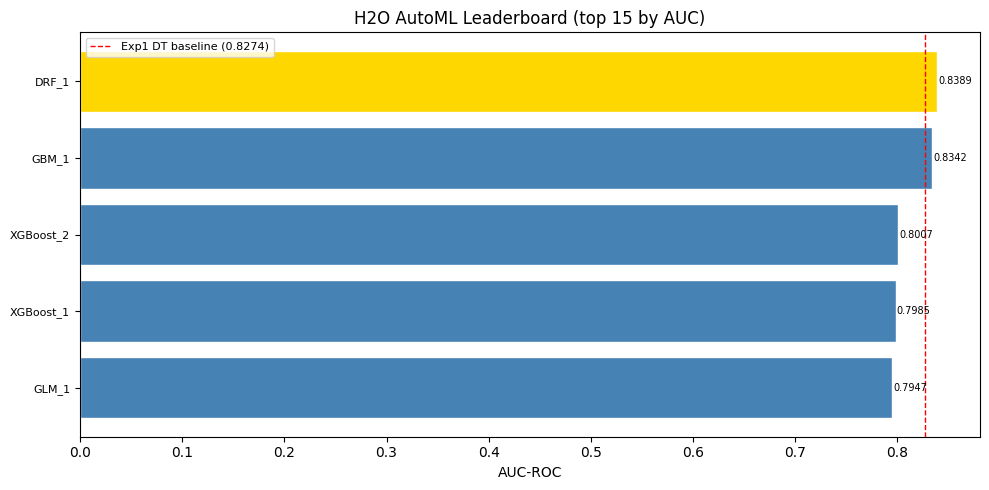

Best model: DRF_1_AutoML_1_20260416_94750


In [11]:
# AUC bar chart — top 15
top_lb = lb.head(15)
fig, ax = plt.subplots(figsize=(10, 5))

colors = ['gold' if i == 0 else 'steelblue' for i in range(len(top_lb))]
bars = ax.barh(range(len(top_lb)), top_lb['auc'].values,
               color=colors, edgecolor='white')
ax.set_yticks(range(len(top_lb)))
ax.set_yticklabels(
    [m.split('_')[0] + '_' + m.split('_')[1] if '_' in m else m
     for m in top_lb['model_id'].values],
    fontsize=8
)
ax.invert_yaxis()
ax.set_xlabel('AUC-ROC')
ax.set_title('H2O AutoML Leaderboard (top 15 by AUC)')
ax.axvline(0.8274, color='red', linestyle='--', linewidth=1, label='Exp1 DT baseline (0.8274)')
ax.legend(fontsize=8)

for bar, val in zip(bars, top_lb['auc'].values):
    ax.text(val + 0.001, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=7)

plt.tight_layout()
plt.show()

print(f'Best model: {aml.leader.model_id}')

# =========================================================
# 8. EVALUATE BEST MODEL
# =========================================================

In [12]:
# Predict on test set
preds_h2o = aml.leader.predict(test_h2o)
preds_df  = preds_h2o.as_data_frame()

y_pred = preds_df['predict'].astype(int).values
y_prob = preds_df['p1'].values   # P(shortage=1)

auc   = roc_auc_score(y_test, y_prob)
prauc = average_precision_score(y_test, y_prob)
f1    = f1_score(y_test, y_pred)
prec  = precision_score(y_test, y_pred)
rec   = recall_score(y_test, y_pred)

print(f'Best model: {aml.leader.model_id}')
print(f'  AUC-ROC  : {auc:.4f}')
print(f'  PR-AUC   : {prauc:.4f}')
print(f'  F1       : {f1:.4f}')
print(f'  Precision: {prec:.4f}')
print(f'  Recall   : {rec:.4f}')
print()
print(classification_report(y_test, y_pred, target_names=['No shortage','Shortage']))

drf prediction progress: |

███████████████████████████████████████████████████████| (done) 100%
Best model: DRF_1_AutoML_1_20260416_94750
  AUC-ROC  : 0.8389
  PR-AUC   : 0.4619
  F1       : 0.3296
  Precision: 0.6586
  Recall   : 0.2198

              precision    recall  f1-score   support

 No shortage       0.90      0.98      0.94     20775
    Shortage       0.66      0.22      0.33      2985

    accuracy                           0.89     23760
   macro avg       0.78      0.60      0.63     23760
weighted avg       0.87      0.89      0.86     23760



/Users/cedrictay/Documents/marketplace-ops-intelligence/.venv/lib/python3.12/site-packages/h2o/frame.py:1983: H2ODependencyWarning: Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using multi-thread, install polars and pyarrow and use it as pandas_df = h2o_df.as_data_frame(use_multi_thread=True)

  warnings.warn("Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using"


In [13]:
# Evaluate top 5 models from leaderboard
print('Top 5 models — detailed metrics on test set:')
print(f'{"Model":<45}  {"AUC":>7}  {"F1":>7}  {"Prec":>7}  {"Recall":>7}')
print('-' * 80)

top5_results = []
for mid in lb['model_id'].values[:5]:
    m  = h2o.get_model(mid)
    p  = m.predict(test_h2o).as_data_frame()
    yp = p['predict'].astype(int).values
    yb = p['p1'].values
    row = {
        'model_id': mid,
        'auc':      round(roc_auc_score(y_test, yb),   4),
        'f1':       round(f1_score(y_test, yp),        4),
        'precision':round(precision_score(y_test, yp), 4),
        'recall':   round(recall_score(y_test, yp),    4),
        '_prob':    yb,
        '_pred':    yp,
    }
    top5_results.append(row)
    short_id = mid[:44]
    print(f'{short_id:<45}  {row["auc"]:>7.4f}  {row["f1"]:>7.4f}  {row["precision"]:>7.4f}  {row["recall"]:>7.4f}')

Top 5 models — detailed metrics on test set:
Model                                              AUC       F1     Prec   Recall
--------------------------------------------------------------------------------
drf prediction progress: |

███████████████████████████████████████████████████████| (done) 100%
DRF_1_AutoML_1_20260416_94750                   0.8389   0.3296   0.6586   0.2198
gbm prediction progress: |

/Users/cedrictay/Documents/marketplace-ops-intelligence/.venv/lib/python3.12/site-packages/h2o/frame.py:1983: H2ODependencyWarning: Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using multi-thread, install polars and pyarrow and use it as pandas_df = h2o_df.as_data_frame(use_multi_thread=True)

  warnings.warn("Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using"


███████████████████████████████████████████████████████| (done) 100%
GBM_1_AutoML_1_20260416_94750                   0.8342   0.4228   0.3600   0.5122
xgboost prediction progress: |

/Users/cedrictay/Documents/marketplace-ops-intelligence/.venv/lib/python3.12/site-packages/h2o/frame.py:1983: H2ODependencyWarning: Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using multi-thread, install polars and pyarrow and use it as pandas_df = h2o_df.as_data_frame(use_multi_thread=True)

  warnings.warn("Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using"


...

/Users/cedrictay/Documents/marketplace-ops-intelligence/.venv/lib/python3.12/site-packages/h2o/frame.py:1983: H2ODependencyWarning: Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using multi-thread, install polars and pyarrow and use it as pandas_df = h2o_df.as_data_frame(use_multi_thread=True)

  warnings.warn("Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using"


███████████████████████████████████████████████████| (done) 100%
XGBoost_1_AutoML_1_20260416_94750               0.7985   0.3643   0.4732   0.2961
glm prediction progress: |

/Users/cedrictay/Documents/marketplace-ops-intelligence/.venv/lib/python3.12/site-packages/h2o/frame.py:1983: H2ODependencyWarning: Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using multi-thread, install polars and pyarrow and use it as pandas_df = h2o_df.as_data_frame(use_multi_thread=True)

  warnings.warn("Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using"


███████████████████████████████████████████████████████| (done) 100%
GLM_1_AutoML_1_20260416_94750                   0.7948   0.4134   0.4300   0.3980


/Users/cedrictay/Documents/marketplace-ops-intelligence/.venv/lib/python3.12/site-packages/h2o/frame.py:1983: H2ODependencyWarning: Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using multi-thread, install polars and pyarrow and use it as pandas_df = h2o_df.as_data_frame(use_multi_thread=True)

  warnings.warn("Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using"


# =========================================================
# 9. THRESHOLD TUNING ON BEST AutoML MODEL
# =========================================================

In [14]:
thresholds = np.arange(0.10, 0.71, 0.05)
thresh_rows = []
for t in thresholds:
    yp_t = (y_prob >= t).astype(int)
    thresh_rows.append({
        'threshold': round(t, 2),
        'f1':        round(f1_score(y_test, yp_t),                    4),
        'precision': round(precision_score(y_test, yp_t, zero_division=0), 4),
        'recall':    round(recall_score(y_test, yp_t),                 4),
        'flagged':   int(yp_t.sum()),
    })

thresh_df = pd.DataFrame(thresh_rows)
print(thresh_df.to_string(index=False))

best_t = thresh_df.loc[thresh_df['f1'].idxmax()]
print(f'\nBest threshold: {best_t["threshold"]}  '
      f'F1={best_t["f1"]:.4f}  Recall={best_t["recall"]:.4f}  Prec={best_t["precision"]:.4f}')

 threshold     f1  precision  recall  flagged
    0.1000 0.4318     0.4204  0.4439     3152
    0.1500 0.4027     0.5084  0.3333     1957
    0.2000 0.3531     0.6114  0.2482     1212
    0.2500 0.3009     0.6833  0.1930      843
    0.3000 0.2505     0.7401  0.1508      608
    0.3500 0.2066     0.7871  0.1189      451
    0.4000 0.1720     0.8412  0.0958      340
    0.4500 0.1484     0.8408  0.0814      289
    0.5000 0.1261     0.8675  0.0680      234
    0.5500 0.1122     0.8647  0.0600      207
    0.6000 0.0963     0.8837  0.0509      172
    0.6500 0.0794     0.8986  0.0415      138
    0.7000 0.0615     0.9048  0.0318      105

Best threshold: 0.1  F1=0.4318  Recall=0.4439  Prec=0.4204


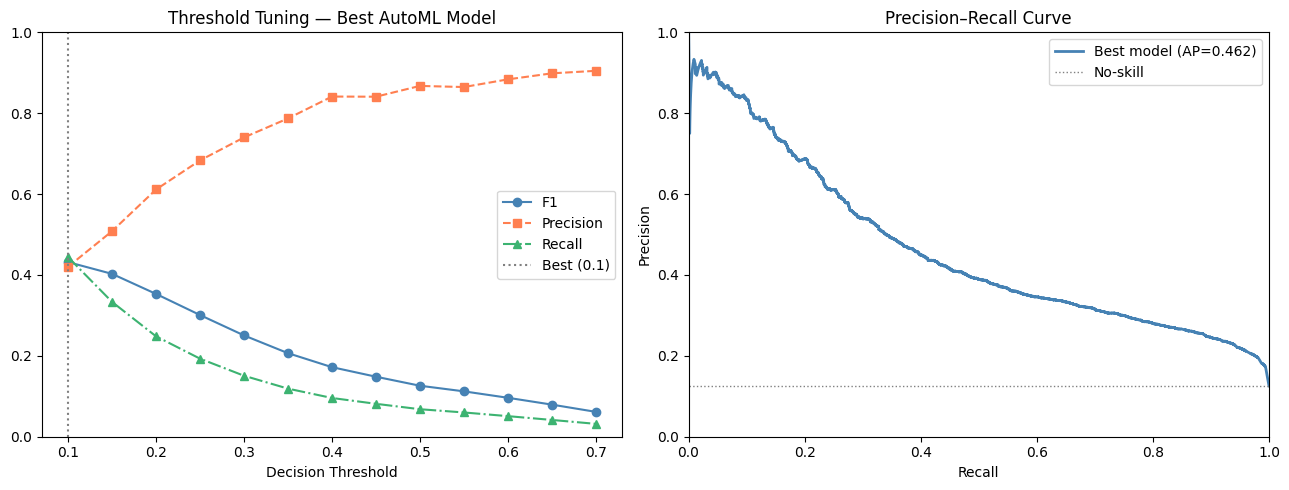

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Threshold curve
ax = axes[0]
ax.plot(thresh_df['threshold'], thresh_df['f1'],        '-o',  label='F1',        color='steelblue')
ax.plot(thresh_df['threshold'], thresh_df['precision'], '--s', label='Precision',  color='coral')
ax.plot(thresh_df['threshold'], thresh_df['recall'],    '-.^', label='Recall',     color='mediumseagreen')
ax.axvline(best_t['threshold'], color='grey', linestyle=':', linewidth=1.5,
           label=f'Best ({best_t["threshold"]})')
ax.set_xlabel('Decision Threshold')
ax.set_title('Threshold Tuning — Best AutoML Model')
ax.legend()
ax.set_ylim(0, 1)

# PR curve
ax2 = axes[1]
prec_c, rec_c, _ = precision_recall_curve(y_test, y_prob)
ap = average_precision_score(y_test, y_prob)
ax2.plot(rec_c, prec_c, color='steelblue', linewidth=2, label=f'Best model (AP={ap:.3f})')
ax2.axhline(y_test.mean(), color='grey', linestyle=':', linewidth=1, label='No-skill')
ax2.set_xlabel('Recall')
ax2.set_ylabel('Precision')
ax2.set_title('Precision–Recall Curve')
ax2.legend()
ax2.set_xlim(0, 1)
ax2.set_ylim(0, 1)

plt.tight_layout()
plt.show()

# =========================================================
# 10. VARIABLE IMPORTANCE (Best Model)
# =========================================================

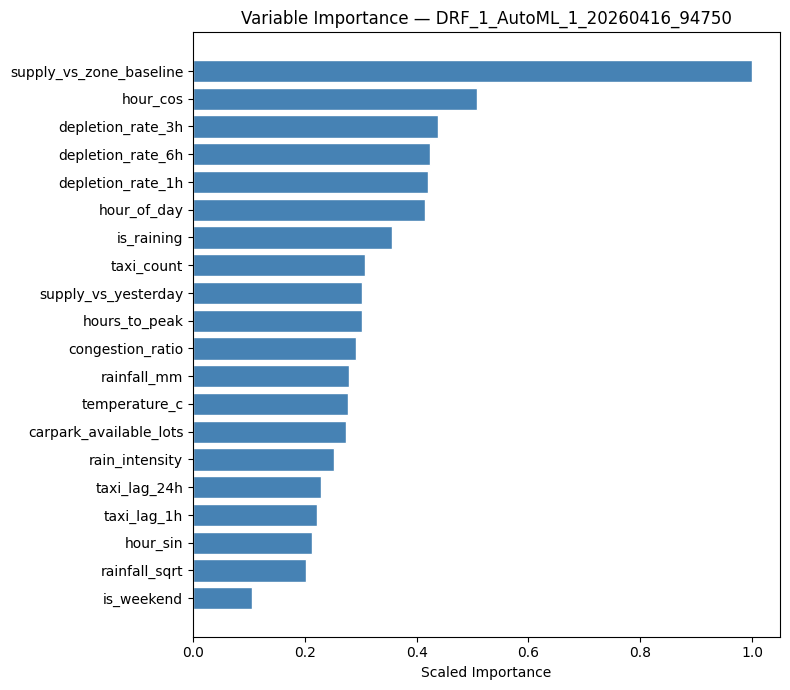

               variable  relative_importance  scaled_importance
supply_vs_zone_baseline          163488.7969             1.0000
               hour_cos           83170.9531             0.5087
      depletion_rate_3h           71669.2188             0.4384
      depletion_rate_6h           69345.5703             0.4242
      depletion_rate_1h           68793.4297             0.4208
            hour_of_day           67904.8125             0.4153
             is_raining           58093.4609             0.3553
             taxi_count           50322.2383             0.3078
    supply_vs_yesterday           49512.5195             0.3028
          hours_to_peak           49323.0352             0.3017
       congestion_ratio           47745.6016             0.2920
            rainfall_mm           45461.2188             0.2781
          temperature_c           45264.6484             0.2769
 carpark_available_lots           44679.3867             0.2733
         rain_intensity           41344.

In [16]:
try:
    vi = aml.leader.varimp(use_pandas=True)
    if vi is not None and not vi.empty:
        vi = vi.head(20)
        fig, ax = plt.subplots(figsize=(8, 7))
        vi_sorted = vi.sort_values('scaled_importance')
        ax.barh(vi_sorted['variable'], vi_sorted['scaled_importance'],
                color='steelblue', edgecolor='white')
        ax.set_xlabel('Scaled Importance')
        ax.set_title(f'Variable Importance — {aml.leader.model_id[:50]}')
        plt.tight_layout()
        plt.show()
        print(vi[['variable','relative_importance','scaled_importance']].to_string(index=False))
    else:
        print('Variable importance not available for this model type (e.g. stacked ensemble).')
        print('Top feature from H2O leaderboard model:')
        # Try getting from base learners
        base_models = aml.leader.params.get('base_models', {}).get('actual', [])
        if base_models:
            bm = h2o.get_model(base_models[0]['name'])
            vi2 = bm.varimp(use_pandas=True)
            if vi2 is not None:
                print(vi2.head(15)[['variable','scaled_importance']].to_string(index=False))
except Exception as e:
    print(f'Variable importance not available: {e}')

# =========================================================
# 11. FULL COMPARISON — All Experiments
# =========================================================

In [17]:
# Apply best threshold to best model
y_pred_best_t = (y_prob >= best_t['threshold']).astype(int)

all_results = [
    {'Experiment': 'Exp1 DT baseline (9 feat)',     'AUC': 0.8274, 'F1': 0.4128, 'Precision': 0.4880, 'Recall': 0.3576},
    {'Experiment': 'Exp2 DT + FE (17 feat)',        'AUC': 0.7669, 'F1': 0.3551, 'Precision': 0.2909, 'Recall': 0.4556},
    {'Experiment': 'Exp3 LGBM + UnderSampling',     'AUC': 0.8084, 'F1': 0.4046, 'Precision': 0.3234, 'Recall': 0.5404},
    {'Experiment': f'Exp4 AutoML ({aml.leader.model_id[:25]}…) default thresh',
     'AUC': round(auc,4), 'F1': round(f1,4), 'Precision': round(prec,4), 'Recall': round(rec,4)},
    {'Experiment': f'Exp4 AutoML best thresh ({best_t["threshold"]})',
     'AUC': round(auc,4),
     'F1':        round(f1_score(y_test, y_pred_best_t), 4),
     'Precision': round(precision_score(y_test, y_pred_best_t, zero_division=0), 4),
     'Recall':    round(recall_score(y_test, y_pred_best_t), 4)},
]

comp_df = pd.DataFrame(all_results)
print('=' * 75)
print('FULL EXPERIMENT COMPARISON')
print('=' * 75)
print(comp_df.to_string(index=False))
print()

# Best overall
best_row = comp_df.loc[comp_df['F1'].idxmax()]
print(f'Best result overall: {best_row["Experiment"]}')
print(f'  AUC={best_row["AUC"]:.4f}  F1={best_row["F1"]:.4f}  '
      f'Prec={best_row["Precision"]:.4f}  Recall={best_row["Recall"]:.4f}')

FULL EXPERIMENT COMPARISON
                                             Experiment    AUC     F1  Precision  Recall
                              Exp1 DT baseline (9 feat) 0.8274 0.4128     0.4880  0.3576
                                 Exp2 DT + FE (17 feat) 0.7669 0.3551     0.2909  0.4556
                              Exp3 LGBM + UnderSampling 0.8084 0.4046     0.3234  0.5404
Exp4 AutoML (DRF_1_AutoML_1_20260416_9…) default thresh 0.8389 0.3296     0.6586  0.2198
                          Exp4 AutoML best thresh (0.1) 0.8389 0.4318     0.4204  0.4439

Best result overall: Exp4 AutoML best thresh (0.1)
  AUC=0.8389  F1=0.4318  Prec=0.4204  Recall=0.4439


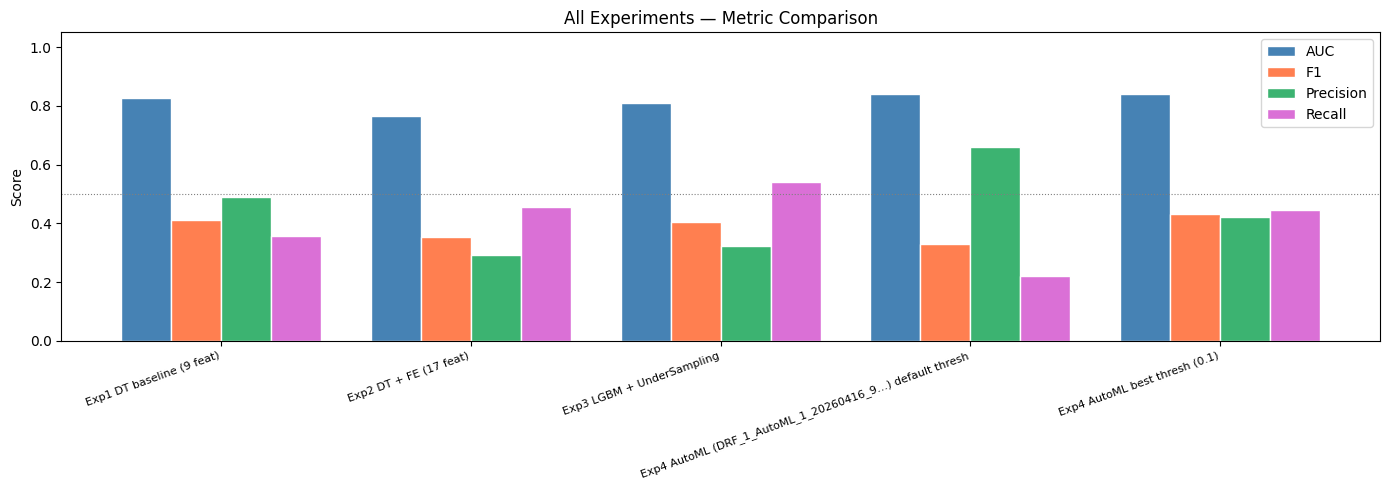

In [18]:
# Visual comparison across experiments
metrics = ['AUC','F1','Precision','Recall']
x = np.arange(len(comp_df))
width = 0.2
colors = ['steelblue','coral','mediumseagreen','orchid']

fig, ax = plt.subplots(figsize=(14, 5))
for i, (metric, color) in enumerate(zip(metrics, colors)):
    bars = ax.bar(x + i*width, comp_df[metric], width, label=metric, color=color, edgecolor='white')

ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(comp_df['Experiment'], rotation=20, ha='right', fontsize=8)
ax.set_ylim(0, 1.05)
ax.set_ylabel('Score')
ax.set_title('All Experiments — Metric Comparison')
ax.legend()
ax.axhline(0.5, color='grey', linestyle=':', linewidth=0.8)
plt.tight_layout()
plt.show()

In [19]:
# Shut down H2O cluster cleanly
h2o.cluster().shutdown()
print('H2O cluster shut down.')

H2O cluster shut down.
